# Green Steel Passport — full pipeline (Colab, single notebook)

Everything in one file: environment setup, EDA, CV subsystem, carbon
regression. Run cells top to bottom.

**Before running the EDA section**: this notebook's setup cells will ask
you to upload `steel_scrap.zip` (or point at Google Drive) and unzip it —
no manual `!unzip` needed elsewhere.


# Part A — Setup

## A1. Runtime / GPU check

In [ ]:
import subprocess, sys, platform

print("Python:", sys.version)
print("Platform:", platform.platform())

try:
    gpu_info = subprocess.run(["nvidia-smi"], capture_output=True, text=True).stdout
    if "NVIDIA" in gpu_info:
        print(gpu_info)
    else:
        raise RuntimeError
except Exception:
    print("⚠ No GPU detected. In Colab: Runtime → Change runtime type → T4 GPU.\n"
          "  CV training (Part C) will be very slow on CPU-only — EDA (Part B) and\n"
          "  carbon regression (Part D) are fine on CPU.")


Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.39
Fri Sep 11 08:34:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                 

## A2. Install dependencies

In [ ]:
!pip install -q torch torchvision opencv-python-headless pandas numpy matplotlib \
    seaborn scikit-learn xgboost shap pyyaml kaggle
print("done")

done


In [ ]:
missing = []
for pkg in ["torch", "torchvision", "cv2", "pandas", "numpy", "matplotlib",
            "seaborn", "sklearn", "xgboost", "shap", "yaml"]:
    try:
        __import__(pkg)
    except ImportError:
        missing.append(pkg)

if missing:
    print(f"⚠ still missing: {missing} — re-run the pip install cell above.")
else:
    print("✓ all required packages import cleanly")

import torch
print("torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())


✓ all required packages import cleanly
torch: 2.11.0+cu128 | CUDA available: True


## A3. Google Drive (optional)
Mount Drive if you want dataset/outputs to persist across Colab sessions.

In [ ]:
MOUNT_DRIVE = False  # flip to True if you want persistence

if MOUNT_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DIR = "/content/drive/MyDrive/green_steel_passport"
else:
    BASE_DIR = "/content"

import os
os.makedirs(BASE_DIR, exist_ok=True)
print("Working base directory:", BASE_DIR)


Working base directory: /content


## A4. Get the scrap-image dataset (`steel_scrap.zip`)
Upload picker opens if the zip isn't already at `BASE_DIR`.

In [ ]:
import os

ZIP_PATH = os.path.join(BASE_DIR, "steel_scrap.zip")
DATA_ROOT = os.path.join(BASE_DIR, "steel_scrap")

if not os.path.exists(ZIP_PATH):
    print("steel_scrap.zip not found at", ZIP_PATH, "— opening upload picker.")
    from google.colab import files
    uploaded = files.upload()  # pick steel_scrap.zip from your machine
    fname = next(iter(uploaded))
    os.replace(fname, ZIP_PATH)

print("Using zip:", ZIP_PATH)


steel_scrap.zip not found at /content/steel_scrap.zip — opening upload picker.


Saving steel scrap.zip to steel scrap.zip
Using zip: /content/steel_scrap.zip


In [ ]:
!unzip -qo "$ZIP_PATH" -d "$DATA_ROOT"
!echo "---" && ls "$DATA_ROOT"

---
 __MACOSX  'steel scrap'


In [ ]:
# Roboflow exports sometimes nest one extra folder level — flatten if so
import os

def find_data_yaml(root):
    for dirpath, _, filenames in os.walk(root):
        if "data.yaml" in filenames:
            return dirpath
    return None

actual_root = find_data_yaml(DATA_ROOT)
if actual_root is None:
    raise FileNotFoundError(f"No data.yaml found anywhere under {DATA_ROOT} — "
                             f"check the zip actually contains the Roboflow export.")
if actual_root != DATA_ROOT:
    print(f"data.yaml found one level deeper, at {actual_root} — using that as DATA_ROOT.")
    DATA_ROOT = actual_root

print("Final DATA_ROOT:", DATA_ROOT)


data.yaml found one level deeper, at /content/steel_scrap/steel scrap — using that as DATA_ROOT.
Final DATA_ROOT: /content/steel_scrap/steel scrap


## A5. Verify dataset layout

In [ ]:
import os, yaml

with open(os.path.join(DATA_ROOT, "data.yaml")) as f:
    cfg = yaml.safe_load(f)

class_names = cfg.get("names", [])
if isinstance(class_names, dict):
    class_names = [class_names[k] for k in sorted(class_names.keys())]
print(f"Classes ({len(class_names)}): {class_names}")

for split in ["train", "valid", "test"]:
    img_dir = os.path.join(DATA_ROOT, split, "images")
    lbl_dir = os.path.join(DATA_ROOT, split, "labels")
    ok = os.path.isdir(img_dir) and os.path.isdir(lbl_dir)
    n_imgs = len(os.listdir(img_dir)) if os.path.isdir(img_dir) else 0
    n_lbls = len(os.listdir(lbl_dir)) if os.path.isdir(lbl_dir) else 0
    status = "✓" if ok and n_imgs == n_lbls and n_imgs > 0 else "⚠"
    print(f"{status} {split}: images={n_imgs}  labels={n_lbls}  dirs_exist={ok}")


Classes (8): ['Homogeneous lots of carbon steel turnings', 'Old and new steel scrap consisting mainly of rebars and merchant bars', 'Old thick steel scrap', 'Old thin steel scrap', 'Shredded steel scrap', 'Thick new production steel scrap', 'Thin new production steel scrap', 'Thin new production steel scrap -compressed or firmly baled-']
✓ train: images=1765  labels=1765  dirs_exist=True
✓ valid: images=159  labels=159  dirs_exist=True
✓ test: images=79  labels=79  dirs_exist=True


## A6. Hugging Face Hub reachability
Needed for `pretrained=True` in Part C to download ImageNet weights.

In [ ]:
import urllib.request

try:
    urllib.request.urlopen("https://huggingface.co", timeout=5)
    print("✓ Hugging Face Hub reachable — pretrained=True will work.")
except Exception as e:
    print(f"⚠ Hugging Face Hub NOT reachable ({e}).\n"
          f"  Training will fall back to random-init weights — flag any resulting\n"
          f"  Section 7.1 numbers as a pipeline-validation run, not a real comparison.")


✓ Hugging Face Hub reachable — pretrained=True will work.


## A7. Kaggle API + EAF process dataset (optional, Layer B)
Only needed for the process/furnace side (Section 4). Get a `kaggle.json` token from https://www.kaggle.com/settings → API → Create New Token.

In [ ]:
# SETUP_KAGGLE = False  # flip to True if you need the EAF dataset this session

# if SETUP_KAGGLE:
#     import os
#     os.makedirs("/root/.kaggle", exist_ok=True)
#     if not os.path.exists("/root/.kaggle/kaggle.json"):
#         from google.colab import files
#         print("Upload your kaggle.json token:")
#         uploaded = files.upload()
#         fname = next(iter(uploaded))
#         os.replace(fname, "/root/.kaggle/kaggle.json")
#         os.chmod("/root/.kaggle/kaggle.json", 0o600)

#     # Industrial Data from the Electric Arc Furnace (Kaggle, HEATID-keyed process tables)
#     !kaggle datasets download -d yuriykatser/industrial-data-from-the-arc-furnace \
#         -p "{BASE_DIR}/eaf_dataset" --unzip
#     print("EAF dataset ready under", os.path.join(BASE_DIR, "eaf_dataset"))
# else:
#     print("Skipped — set SETUP_KAGGLE = True and fill in the dataset slug when you need it.")


In [ ]:
SETUP_KAGGLE = True  # flip to True if you need the EAF dataset this session

if SETUP_KAGGLE:
    import kagglehub, shutil, os

    path = kagglehub.dataset_download("yuriykatser/industrial-data-from-the-arc-furnace")
    print("Downloaded to:", path)

    eaf_dir = os.path.join(BASE_DIR, "eaf_dataset")
    if os.path.abspath(path) != os.path.abspath(eaf_dir):
        if os.path.exists(eaf_dir):
            shutil.rmtree(eaf_dir)
        shutil.copytree(path, eaf_dir)

    print("EAF dataset files:", os.listdir(eaf_dir))
    print("EAF dataset ready under", eaf_dir)
else:
    print("Skipped — set SETUP_KAGGLE = True when you need the EAF dataset.")

100%|██████████| 100M/100M [00:06<00:00, 16.0MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/yuriykatser/industrial-data-from-the-arc-furnace/versions/3
EAF dataset files: ['ferro.csv', 'eaf_temp.csv', 'lf_added_materials.csv', 'lf_initial_chemical_measurements.csv', 'inj_mat.csv', 'eaf_gaslance_mat.csv', 'ladle_tapping.csv', 'eaf_final_chemical_measurements.csv', 'eaf_transformer.csv', 'eaf_added_materials.csv', 'basket_charged.csv']
EAF dataset ready under /content/eaf_dataset


## A8. Output directories

In [ ]:
import os

EDA_OUT = os.path.join(BASE_DIR, "eda_outputs")
CV_OUT = os.path.join(BASE_DIR, "cv_outputs")
ML_OUT = os.path.join(BASE_DIR, "ml_outputs")

for d in [EDA_OUT, CV_OUT, ML_OUT]:
    os.makedirs(d, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("EDA_OUT   :", EDA_OUT)
print("CV_OUT    :", CV_OUT)
print("ML_OUT    :", ML_OUT)
print("\nSetup complete — these variables carry straight into Parts B/C/D below.")


DATA_ROOT: /content/steel_scrap/steel scrap
EDA_OUT   : /content/eda_outputs
CV_OUT    : /content/cv_outputs
ML_OUT    : /content/ml_outputs

Setup complete — these variables carry straight into Parts B/C/D below.


# Part B — EDA (`01_eda_analysis.py`)
Reads the unzipped Roboflow export and writes slide-ready EDA figures.

Classes (8): ['Homogeneous lots of carbon steel turnings', 'Old and new steel scrap consisting mainly of rebars and merchant bars', 'Old thick steel scrap', 'Old thin steel scrap', 'Shredded steel scrap', 'Thick new production steel scrap', 'Thin new production steel scrap', 'Thin new production steel scrap -compressed or firmly baled-']
Scanned 2003 images across ['train', 'valid', 'test']


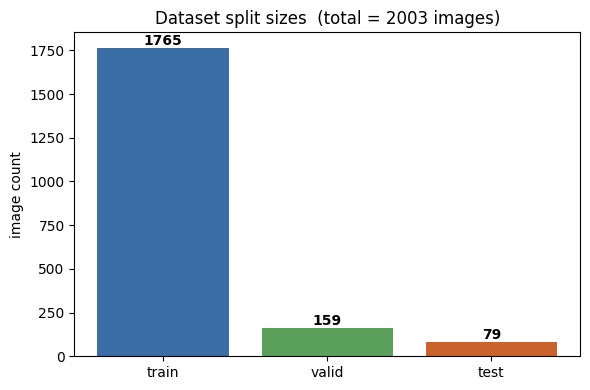

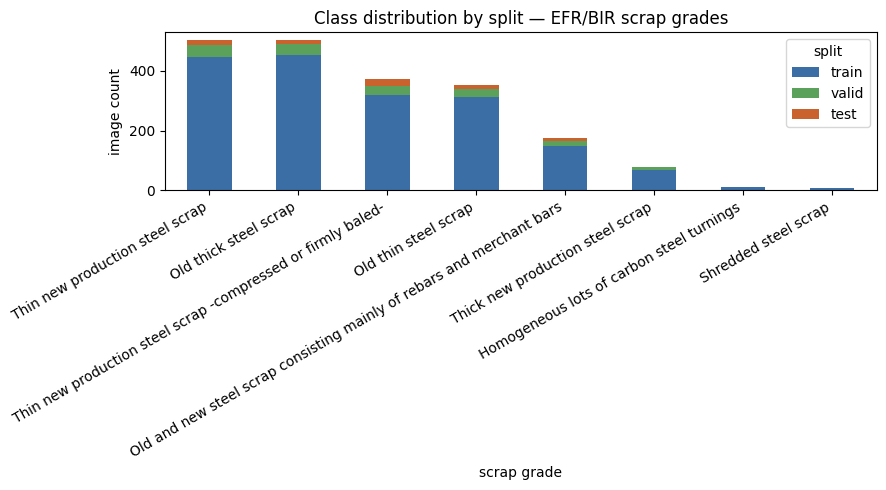

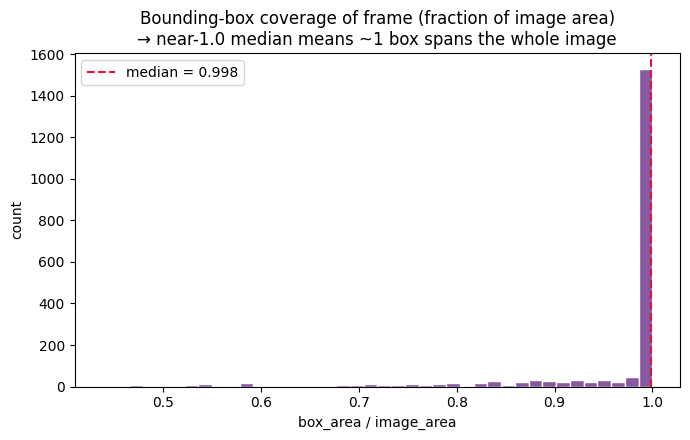

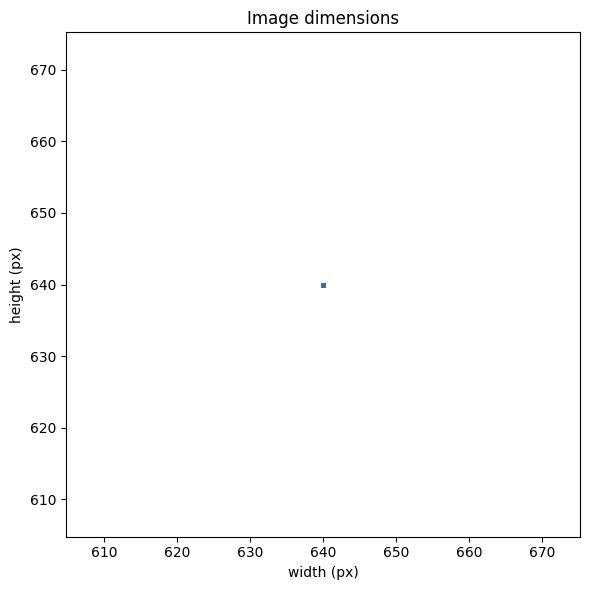

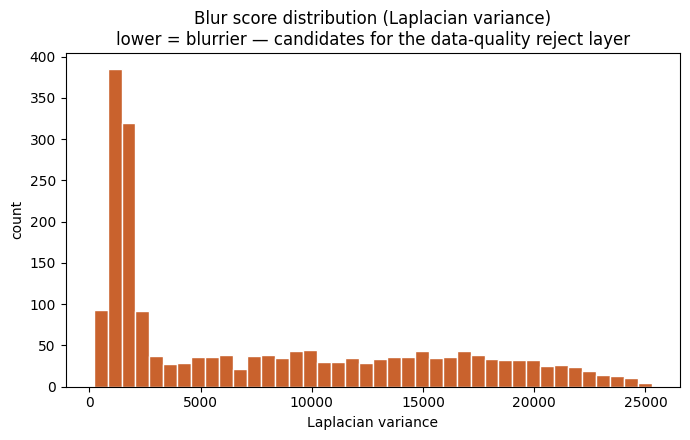

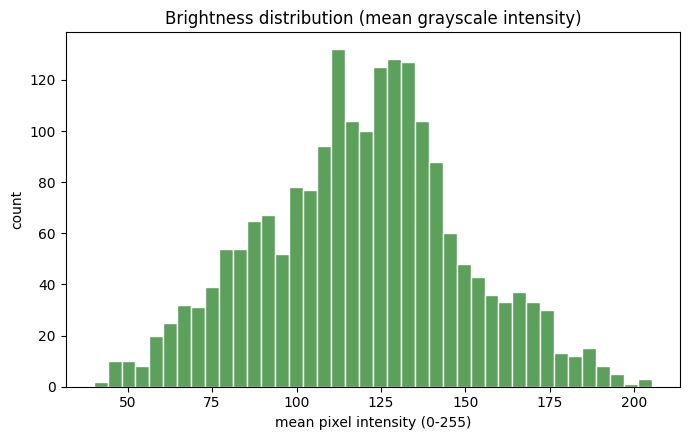

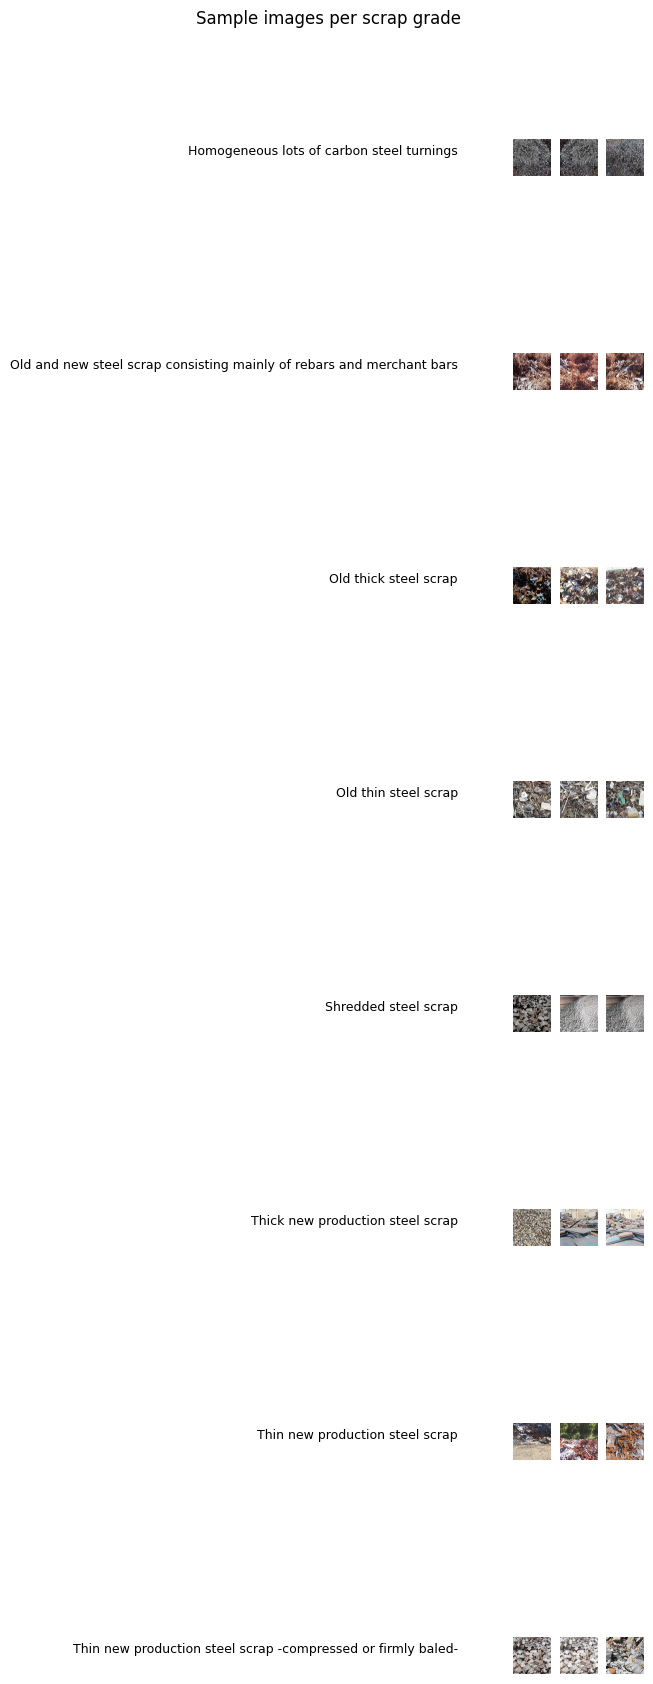

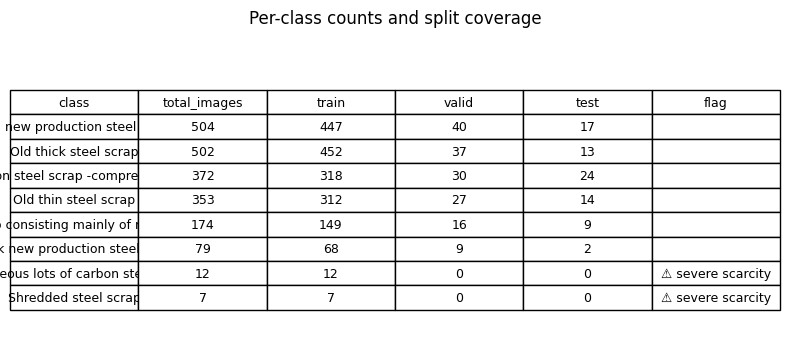


=== EDA summary ===
total_images: 2003
n_classes: 8
median_box_coverage: 0.9984375
pct_images_box_covers_gt_90pct: 85.12231652521218
min_class_count: 7
max_class_count: 504
imbalance_ratio_max_min: 72.0
mean_blur: 7764.525571277366
pct_low_blur_lt_p10: 10.034947578632051

All figures written to /content/eda_outputs/

=== What this means ===
- 2003 images across 8 scrap grades.
- Median box coverage is 0.998 of the frame (85.1% of images have a box over 90% of the frame) — this dataset is effectively one label per image, not per-object boxes. That's the evidence for treating this as pile-level classification rather than object detection.
- Class imbalance is severe: 72:1 (largest class 504 images, smallest 7). Expect the smallest class(es) to be unreliable to learn without class weighting or oversampling — script 2 already applies class-weighted loss for this.
- 10.0% of images sit in the bottom 10% for sharpness — candidates for the data-quality reject layer (Section 3.7) rather than 

{'total_images': 2003,
 'n_classes': 8,
 'median_box_coverage': 0.9984375,
 'pct_images_box_covers_gt_90pct': 85.12231652521218,
 'min_class_count': 7,
 'max_class_count': 504,
 'imbalance_ratio_max_min': 72.0,
 'mean_blur': 7764.525571277366,
 'pct_low_blur_lt_p10': 10.034947578632051}

In [ ]:
"""
Green Steel Passport — Layer A (vision dataset) EDA
=====================================================
Run against the Roboflow YOLOv8 export (steel_scrap.zip, unzipped) with the
standard layout:

    dataset_root/
        data.yaml
        train/images/*.jpg   train/labels/*.txt
        valid/images/*.jpg   valid/labels/*.txt
        test/images/*.jpg    test/labels/*.txt

Each label .txt is YOLO format: `class_id cx cy w h` (normalized), one line
per object. As established in the prior pipeline audit, this dataset has
~1 box per image covering ~99.8% of the frame — i.e. it is a full-pile
grade classification dataset wearing detection-file formatting. This EDA
surfaces exactly that finding (box-coverage histogram) alongside the
usual class balance / image-quality checks, so the same evidence that
justified the pile-level classification reframing (Section 3.1 vs 6.1 in
the approach doc) shows up on a slide.

Usage:
    python 01_eda_analysis.py --data_root /path/to/steel_scrap --out ./eda_outputs

Outputs (all PNG, ready to drop into slides) + a summary_stats.csv:
    class_distribution.png       — per-class count, per split, stacked
    split_sizes.png              — images per split
    box_coverage_hist.png        — box-area / image-area distribution (the
                                    "this is classification, not detection" plot)
    image_dimensions.png         — width/height scatter
    blur_score_hist.png          — Laplacian-variance blur distribution
    brightness_hist.png          — mean-pixel-intensity distribution
    sample_grid.png              — N sample images per class
    class_imbalance_table.png    — rendered table image (severe classes flagged)
"""
import argparse
import os
import sys
import random
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib
# Headless backend only for plain `python script.py` runs — inside Jupyter/Colab
# (get_ipython() exists) this is skipped so plt.show() below actually renders
# inline instead of silently overriding the notebook's own inline backend.
try:
    get_ipython()  # noqa: F821
    _IN_NOTEBOOK = True
except NameError:
    _IN_NOTEBOOK = False
if not _IN_NOTEBOOK:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import cv2
import yaml


def load_class_names(data_root):
    yaml_path = os.path.join(data_root, "data.yaml")
    if os.path.exists(yaml_path):
        with open(yaml_path) as f:
            cfg = yaml.safe_load(f)
        names = cfg.get("names", [])
        if isinstance(names, dict):
            # {0: 'E1', 1: 'E2', ...}
            names = [names[k] for k in sorted(names.keys())]
        return names
    return None


def scan_split(data_root, split, class_names):
    """Returns a DataFrame: one row per image with class(es), box coverage, dims, quality."""
    img_dir = os.path.join(data_root, split, "images")
    lbl_dir = os.path.join(data_root, split, "labels")
    if not os.path.isdir(img_dir):
        return pd.DataFrame()

    rows = []
    img_files = sorted([f for f in os.listdir(img_dir)
                         if f.lower().endswith((".jpg", ".jpeg", ".png"))])

    for fname in img_files:
        img_path = os.path.join(img_dir, fname)
        stem = os.path.splitext(fname)[0]
        lbl_path = os.path.join(lbl_dir, stem + ".txt")

        img = cv2.imread(img_path)
        if img is None:
            rows.append(dict(split=split, filename=fname, class_id=-1,
                              class_name="UNREADABLE", width=None, height=None,
                              n_boxes=0, box_coverage=None, blur=None, brightness=None))
            continue

        h, w = img.shape[:2]
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        blur = cv2.Laplacian(gray, cv2.CV_64F).var()
        brightness = gray.mean()

        classes, coverages = [], []
        if os.path.exists(lbl_path):
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cid = int(float(parts[0]))
                    bw, bh = float(parts[3]), float(parts[4])
                    classes.append(cid)
                    coverages.append(bw * bh)  # fraction of frame area

        # dominant class = first (in this dataset there's ~1 box/image anyway)
        cid = classes[0] if classes else -1
        cname = class_names[cid] if class_names and 0 <= cid < len(class_names) else str(cid)

        rows.append(dict(
            split=split, filename=fname, class_id=cid, class_name=cname,
            width=w, height=h, n_boxes=len(classes),
            box_coverage=np.mean(coverages) if coverages else None,
            blur=blur, brightness=brightness,
        ))

    return pd.DataFrame(rows)


def run_eda(data_root, out="./eda_outputs", samples_per_class=3):
    """Notebook-callable entry point — same logic the CLI (`main()` below) runs,
    just as a plain function so it works in Colab/Jupyter cells without argparse
    fighting the kernel launcher's own argv. Returns the summary dict.

    Example (Colab cell):
        run_eda(data_root="/content/steel_scrap", out="/content/eda_outputs")
    """
    args = argparse.Namespace(data_root=data_root, out=out, samples_per_class=samples_per_class)
    return _run(args)


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--data_root", required=True, help="Path to unzipped Roboflow export")
    ap.add_argument("--out", default="./eda_outputs")
    ap.add_argument("--samples_per_class", type=int, default=3)
    args, _unknown = ap.parse_known_args()
    _run(args)


def _run(args):
    os.makedirs(args.out, exist_ok=True)
    class_names = load_class_names(args.data_root)
    if class_names:
        print(f"Classes ({len(class_names)}): {class_names}")

    splits = ["train", "valid", "test"]
    dfs = [scan_split(args.data_root, s, class_names) for s in splits]
    df = pd.concat(dfs, ignore_index=True)
    if df.empty:
        sys.exit(f"No images found under {args.data_root}/{{train,valid,test}}/images — check --data_root.")

    df.to_csv(os.path.join(args.out, "eda_raw_table.csv"), index=False)
    print(f"Scanned {len(df)} images across {[s for s in splits if not df[df.split==s].empty]}")

    sns_palette = "viridis"

    # 1. Split sizes ---------------------------------------------------
    plt.figure(figsize=(6, 4))
    counts = df.groupby("split").size().reindex(splits).fillna(0)
    bars = plt.bar(counts.index, counts.values, color=["#3b6ea5", "#5ba05b", "#c9622d"])
    for b, v in zip(bars, counts.values):
        plt.text(b.get_x() + b.get_width() / 2, v + max(counts.values) * 0.01,
                  f"{int(v)}", ha="center", fontweight="bold")
    plt.title(f"Dataset split sizes  (total = {len(df)} images)")
    plt.ylabel("image count")
    plt.tight_layout()
    plt.savefig(os.path.join(args.out, "split_sizes.png"), dpi=150)
    plt.show()  # renders inline in notebooks; no-op under Agg for CLI runs
    plt.close()

    # 2. Class distribution per split (stacked) -------------------------
    ct = pd.crosstab(df["class_name"], df["split"]).reindex(columns=splits, fill_value=0)
    ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]
    ax = ct.plot(kind="bar", stacked=True, figsize=(9, 5),
                 color=["#3b6ea5", "#5ba05b", "#c9622d"])
    plt.title("Class distribution by split — EFR/BIR scrap grades")
    plt.xlabel("scrap grade")
    plt.ylabel("image count")
    plt.xticks(rotation=30, ha="right")
    plt.legend(title="split")
    plt.tight_layout()
    plt.savefig(os.path.join(args.out, "class_distribution.png"), dpi=150)
    plt.show()  # renders inline in notebooks; no-op under Agg for CLI runs
    plt.close()

    # 3. Box coverage histogram — "this is classification not detection" --
    cov = df["box_coverage"].dropna()
    plt.figure(figsize=(7, 4.5))
    plt.hist(cov, bins=40, color="#8858a0", edgecolor="white")
    plt.axvline(cov.median(), color="crimson", linestyle="--",
                label=f"median = {cov.median():.3f}")
    plt.title("Bounding-box coverage of frame (fraction of image area)\n"
              "→ near-1.0 median means ~1 box spans the whole image")
    plt.xlabel("box_area / image_area")
    plt.ylabel("count")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(args.out, "box_coverage_hist.png"), dpi=150)
    plt.show()  # renders inline in notebooks; no-op under Agg for CLI runs
    plt.close()

    # 4. Image dimensions -------------------------------------------------
    plt.figure(figsize=(6, 6))
    plt.scatter(df["width"], df["height"], s=6, alpha=0.4, c="#3b6ea5")
    plt.title("Image dimensions")
    plt.xlabel("width (px)")
    plt.ylabel("height (px)")
    plt.tight_layout()
    plt.savefig(os.path.join(args.out, "image_dimensions.png"), dpi=150)
    plt.show()  # renders inline in notebooks; no-op under Agg for CLI runs
    plt.close()

    # 5. Blur (Laplacian variance) — data-quality layer signal -----------
    plt.figure(figsize=(7, 4.5))
    plt.hist(df["blur"].dropna(), bins=40, color="#c9622d", edgecolor="white")
    plt.title("Blur score distribution (Laplacian variance)\nlower = blurrier — candidates for the data-quality reject layer")
    plt.xlabel("Laplacian variance")
    plt.ylabel("count")
    plt.tight_layout()
    plt.savefig(os.path.join(args.out, "blur_score_hist.png"), dpi=150)
    plt.show()  # renders inline in notebooks; no-op under Agg for CLI runs
    plt.close()

    # 6. Brightness ---------------------------------------------------
    plt.figure(figsize=(7, 4.5))
    plt.hist(df["brightness"].dropna(), bins=40, color="#5ba05b", edgecolor="white")
    plt.title("Brightness distribution (mean grayscale intensity)")
    plt.xlabel("mean pixel intensity (0-255)")
    plt.ylabel("count")
    plt.tight_layout()
    plt.savefig(os.path.join(args.out, "brightness_hist.png"), dpi=150)
    plt.show()  # renders inline in notebooks; no-op under Agg for CLI runs
    plt.close()

    # 7. Sample grid per class -----------------------------------------
    classes_present = [c for c in df["class_name"].unique() if c not in ("UNREADABLE",)]
    n_cls = len(classes_present)
    k = args.samples_per_class
    fig, axes = plt.subplots(n_cls, k, figsize=(k * 2.2, n_cls * 2.2))
    if n_cls == 1:
        axes = np.array([axes])
    for i, cname in enumerate(sorted(classes_present)):
        sub = df[df["class_name"] == cname]
        picks = sub.sample(min(k, len(sub)), random_state=0)
        for j in range(k):
            ax = axes[i, j] if n_cls > 1 else axes[j]
            ax.axis("off")
            if j < len(picks):
                row = picks.iloc[j]
                img_path = os.path.join(args.data_root, row["split"], "images", row["filename"])
                img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
                ax.imshow(img)
            if j == 0:
                ax.set_ylabel(cname, rotation=0, labelpad=40, fontsize=9, ha="right")
                ax.axis("on")
                ax.set_xticks([]); ax.set_yticks([])
                for spine in ax.spines.values():
                    spine.set_visible(False)
    plt.suptitle("Sample images per scrap grade", y=1.0)
    plt.tight_layout()
    plt.savefig(os.path.join(args.out, "sample_grid.png"), dpi=150, bbox_inches="tight")
    plt.show()  # renders inline in notebooks; no-op under Agg for CLI runs
    plt.close()

    # 8. Class imbalance table (rendered) --------------------------------
    total_counts = df["class_name"].value_counts()
    imbalance_df = pd.DataFrame({
        "class": total_counts.index,
        "total_images": total_counts.values,
        "train": [ct.loc[c, "train"] if c in ct.index else 0 for c in total_counts.index],
        "valid": [ct.loc[c, "valid"] if c in ct.index else 0 for c in total_counts.index],
        "test":  [ct.loc[c, "test"]  if c in ct.index else 0 for c in total_counts.index],
    })
    imbalance_df["flag"] = np.where(imbalance_df["total_images"] < 20, "⚠ severe scarcity", "")
    imbalance_df.to_csv(os.path.join(args.out, "class_imbalance_table.csv"), index=False)

    fig, ax = plt.subplots(figsize=(8, 0.5 + 0.4 * len(imbalance_df)))
    ax.axis("off")
    tbl = ax.table(cellText=imbalance_df.values, colLabels=imbalance_df.columns,
                    cellLoc="center", loc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.4)
    plt.title("Per-class counts and split coverage", pad=20)
    plt.tight_layout()
    plt.savefig(os.path.join(args.out, "class_imbalance_table.png"), dpi=150, bbox_inches="tight")
    plt.show()  # renders inline in notebooks; no-op under Agg for CLI runs
    plt.close()

    # 9. Summary stats CSV ------------------------------------------------
    summary = {
        "total_images": len(df),
        "n_classes": df["class_name"].nunique(),
        "median_box_coverage": float(cov.median()),
        "pct_images_box_covers_gt_90pct": float((cov > 0.90).mean() * 100),
        "min_class_count": int(total_counts.min()),
        "max_class_count": int(total_counts.max()),
        "imbalance_ratio_max_min": float(total_counts.max() / max(total_counts.min(), 1)),
        "mean_blur": float(df["blur"].mean()),
        "pct_low_blur_lt_p10": float((df["blur"] < df["blur"].quantile(0.10)).mean() * 100),
    }
    pd.Series(summary).to_csv(os.path.join(args.out, "summary_stats.csv"))
    print("\n=== EDA summary ===")
    for k_, v_ in summary.items():
        print(f"{k_}: {v_}")
    print(f"\nAll figures written to {args.out}/")

    print("\n=== What this means ===")
    print(f"- {summary['total_images']} images across {summary['n_classes']} scrap grades.")
    if summary["median_box_coverage"] > 0.9:
        print(f"- Median box coverage is {summary['median_box_coverage']:.3f} of the frame "
              f"({summary['pct_images_box_covers_gt_90pct']:.1f}% of images have a box over 90% of the "
              f"frame) — this dataset is effectively one label per image, not per-object boxes. That's the "
              f"evidence for treating this as pile-level classification rather than object detection.")
    ratio = summary["imbalance_ratio_max_min"]
    if ratio > 10:
        print(f"- Class imbalance is severe: {ratio:.0f}:1 (largest class {summary['max_class_count']} "
              f"images, smallest {summary['min_class_count']}). Expect the smallest class(es) to be "
              f"unreliable to learn without class weighting or oversampling — script 2 already applies "
              f"class-weighted loss for this.")
    if summary["pct_low_blur_lt_p10"] > 0:
        print(f"- {summary['pct_low_blur_lt_p10']:.1f}% of images sit in the bottom 10% for sharpness — "
              f"candidates for the data-quality reject layer (Section 3.7) rather than automatic exclusion.")
    return summary


# (CLI entry point omitted in notebook — call run_eda(...) directly below)


# ---- uses DATA_ROOT / EDA_OUT from Part A — override here if needed ----
run_eda(
    data_root=DATA_ROOT,
    out=EDA_OUT,
)


# Part C — CV subsystem (`02_cv_pipeline.py`)
ResNet / ViT / Swin classifier, split conformal prediction, Score-CAM.
Run this cell once per architecture (edit `model=` below) to fill in the Section 7.1 comparison table — each run appends a row to `cv_outputs/model_comparison.csv`.

Device: cuda
train=1765 valid=159 test=79
Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 174MB/s]


[swin_t] epoch 1/15  loss=0.6287  val_acc=0.9748
[swin_t] epoch 2/15  loss=0.2524  val_acc=0.9937
[swin_t] epoch 3/15  loss=0.1644  val_acc=0.8994
[swin_t] epoch 4/15  loss=0.1488  val_acc=0.9874
[swin_t] epoch 5/15  loss=0.0845  val_acc=0.9748
[swin_t] epoch 6/15  loss=0.0759  val_acc=0.9434
[swin_t] epoch 7/15  loss=0.0460  val_acc=0.9811
[swin_t] epoch 8/15  loss=0.0380  val_acc=0.9686
[swin_t] epoch 9/15  loss=0.0457  val_acc=0.9748
[swin_t] epoch 10/15  loss=0.0453  val_acc=0.9811
[swin_t] epoch 11/15  loss=0.0239  val_acc=0.9748
[swin_t] epoch 12/15  loss=0.0163  val_acc=0.9748
[swin_t] epoch 13/15  loss=0.0245  val_acc=0.9748
[swin_t] epoch 14/15  loss=0.0227  val_acc=0.9748
[swin_t] epoch 15/15  loss=0.0189  val_acc=0.9748


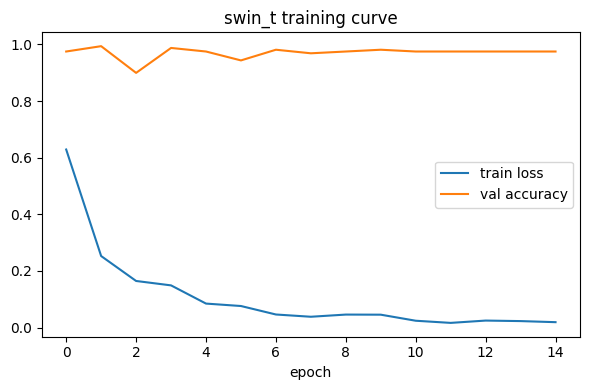

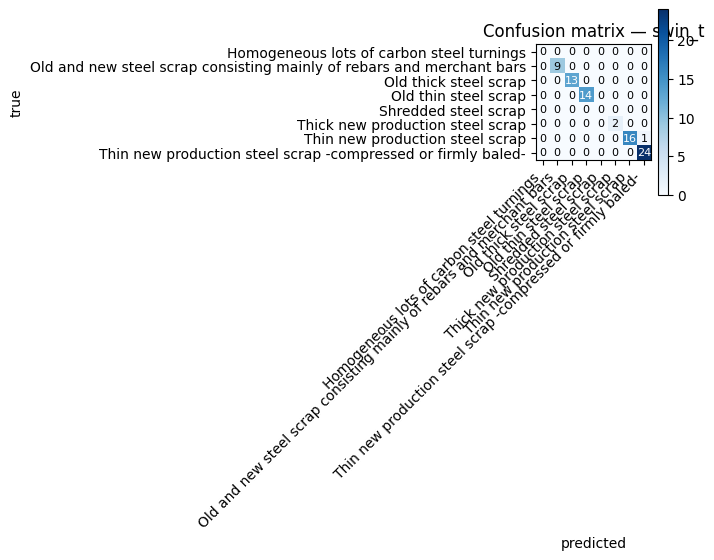

[swin_t] TEST metrics: {'accuracy': 0.9873417721518988, 'macro_precision': 0.745, 'macro_recall': 0.7426470588235294, 'macro_f1': 0.743661100803958}


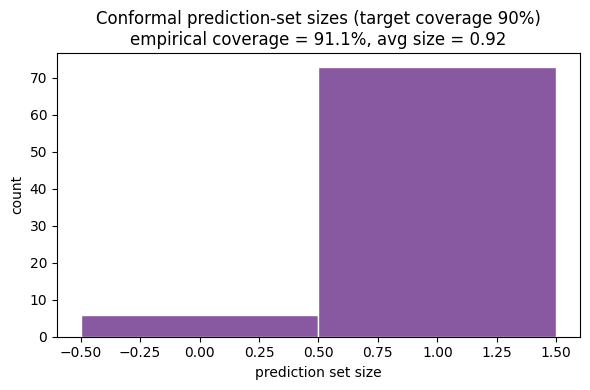

[swin_t] conformal: {'target_coverage': 0.9, 'empirical_coverage': 0.9113924050632911, 'avg_prediction_set_size': 0.9240506329113924, 'pct_singleton_sets': 92.40506329113924, 'pct_empty_sets': 7.59493670886076}

Updated comparison table -> /content/cv_outputs/model_comparison.csv

=== What this means ===
- swin_t: test accuracy 0.987, but macro-F1 is 0.744 — that gap is expected with severe class imbalance (see EDA): accuracy is pulled up by the common classes while macro-F1 weights every class equally, exposing how the rare classes do.
- Conformal coverage: 91.1% empirical vs 90.0% target — well-calibrated, averaging 0.92 classes per prediction set (92% singleton — the model is confident and correct most of the time, with the prediction set widening on the harder/rarer cases).


/tmp/ipykernel_1177/3312874011.py:324: UserWarning: Score-CAM example wired for ResNet (`layer4`). For ViT/Swin use attention-rollout instead — not implemented here.
  warnings.warn("Score-CAM example wired for ResNet (`layer4`). "


{'model': 'swin_t',
 'pretrained': True,
 'epochs': 15,
 'accuracy': 0.9873417721518988,
 'macro_precision': 0.745,
 'macro_recall': 0.7426470588235294,
 'macro_f1': 0.743661100803958,
 'target_coverage': 0.9,
 'empirical_coverage': 0.9113924050632911,
 'avg_prediction_set_size': 0.9240506329113924,
 'pct_singleton_sets': 92.40506329113924,
 'pct_empty_sets': 7.59493670886076}

In [ ]:
"""
Green Steel Passport — CV subsystem (Section 3, reframed per 3.1→pile-level
classification decision): ResNet / ViT / Swin comparison, Split Conformal
Prediction (3.3), and Score-CAM explainability (3.4).

The dataset ships in YOLO-detection format but is functionally a
one-label-per-image grade classification set (median box covers ~99.8%
of the frame — see 01_eda_analysis.py). This script reads the YOLO label's
first class id as the image-level grade label and trains a standard
image classifier — Layer A / Phase 1 of Section 6.5.

Pipeline stages:
    1. Dataset          — reads Roboflow YOLOv8 export, image-level label
    2. Model zoo         — ResNet18, ViT-B/16, Swin-T (torchvision, ImageNet
                            pretrained where network allows; falls back to
                            random init with a clear warning otherwise)
    3. Training loop      — class-weighted CE loss (severe imbalance), AMP
    4. Evaluation         — accuracy / precision / recall / F1 / confusion matrix
                            (this is the Section 7.1 model-comparison table)
    5. Split Conformal    — calibrate on the valid split, evaluate coverage +
                            avg prediction-set size on test (Section 3.3)
    6. Score-CAM          — visual evidence overlay for a handful of test
                            images (Section 3.4), CNN-based (ResNet)

Usage:
    python 02_cv_pipeline.py --data_root /path/to/steel_scrap \
        --model resnet18 --epochs 15 --pretrained --out ./cv_outputs

    # run all three architectures for the Section 7.1 comparison table:
    for m in resnet18 vit_b_16 swin_t; do
        python 02_cv_pipeline.py --data_root ./steel_scrap --model $m \
            --epochs 15 --pretrained --out ./cv_outputs
    done
"""
import argparse
import json
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib
# Headless backend only for plain `python script.py` runs — inside Jupyter/Colab
# (get_ipython() exists) this is skipped so plt.show() below actually renders
# inline instead of silently overriding the notebook's own inline backend.
try:
    get_ipython()  # noqa: F821
    _IN_NOTEBOOK = True
except NameError:
    _IN_NOTEBOOK = False
if not _IN_NOTEBOOK:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms, models
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              confusion_matrix, classification_report)


# ----------------------------------------------------------------------
# 1. Dataset
# ----------------------------------------------------------------------
class ScrapGradeDataset(Dataset):
    """Reads a Roboflow YOLOv8-export split as an image-level classification set:
    the label is the class_id of the first (dominant) box in the .txt file."""

    def __init__(self, data_root, split, class_names, transform=None):
        self.img_dir = os.path.join(data_root, split, "images")
        self.lbl_dir = os.path.join(data_root, split, "labels")
        self.transform = transform
        self.class_names = class_names
        self.samples = []  # (image_path, class_id)

        for fname in sorted(os.listdir(self.img_dir)):
            if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            stem = os.path.splitext(fname)[0]
            lbl_path = os.path.join(self.lbl_dir, stem + ".txt")
            if not os.path.exists(lbl_path):
                continue
            with open(lbl_path) as f:
                first_line = f.readline().strip().split()
            if not first_line:
                continue
            cid = int(float(first_line[0]))
            self.samples.append((os.path.join(self.img_dir, fname), cid))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, cid = self.samples[idx]
        img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(img)
        return img, cid, path

    def class_counts(self):
        c = np.zeros(len(self.class_names), dtype=int)
        for _, cid in self.samples:
            c[cid] += 1
        return c


def get_transforms(img_size=224):
    mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]  # ImageNet stats
    train_tf = transforms.Compose([
        transforms.ToPILImage(),
        transforms.RandomResizedCrop(img_size, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    eval_tf = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    return train_tf, eval_tf


# ----------------------------------------------------------------------
# 2. Model zoo
# ----------------------------------------------------------------------
def build_model(name, n_classes, pretrained=True):
    weights_kw = {}
    try:
        if name == "resnet18":
            weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
            m = models.resnet18(weights=weights)
            m.fc = nn.Linear(m.fc.in_features, n_classes)
        elif name == "vit_b_16":
            weights = models.ViT_B_16_Weights.IMAGENET1K_V1 if pretrained else None
            m = models.vit_b_16(weights=weights)
            m.heads.head = nn.Linear(m.heads.head.in_features, n_classes)
        elif name == "swin_t":
            weights = models.Swin_T_Weights.IMAGENET1K_V1 if pretrained else None
            m = models.swin_t(weights=weights)
            m.head = nn.Linear(m.head.in_features, n_classes)
        else:
            raise ValueError(f"unknown model {name}")
    except Exception as e:
        warnings.warn(f"Pretrained weights unavailable ({e}); using random init. "
                       f"Flag this result as a pipeline-validation run, not a real "
                       f"Section 7.1 number (pretraining matters a lot on small data).")
        return build_model(name, n_classes, pretrained=False)
    return m


# ----------------------------------------------------------------------
# 3 + 4. Train / evaluate
# ----------------------------------------------------------------------
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, n = 0.0, 0
    for imgs, labels, _ in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        n += imgs.size(0)
    return total_loss / max(n, 1)


@torch.no_grad()
def get_probs(model, loader, device):
    model.eval()
    all_probs, all_labels, all_paths = [], [], []
    for imgs, labels, paths in loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        probs = F.softmax(logits, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.numpy())
        all_paths.extend(paths)
    return np.concatenate(all_probs), np.concatenate(all_labels), all_paths


def evaluate(probs, labels, class_names, out_dir, tag):
    preds = probs.argmax(axis=1)
    all_labels = list(range(len(class_names)))  # pin the full label set —
    # otherwise sklearn infers it from whichever classes actually appear in
    # this batch, which is fewer than len(class_names) whenever a rare class
    # (e.g. classes 0/4, per the EDA's 72:1 imbalance finding) is absent from
    # a given split/batch, causing "Number of classes, N, does not match
    # size of target_names" against the fixed 8-name list.
    acc = accuracy_score(labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        labels, preds, labels=all_labels, average="macro", zero_division=0)
    report = classification_report(labels, preds, labels=all_labels, target_names=class_names,
                                    zero_division=0, output_dict=True)
    pd.DataFrame(report).transpose().to_csv(os.path.join(out_dir, f"{tag}_classification_report.csv"))

    cm = confusion_matrix(labels, preds, labels=all_labels)
    plt.figure(figsize=(7, 6))
    plt.imshow(cm, cmap="Blues")
    plt.colorbar()
    plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
    plt.yticks(range(len(class_names)), class_names)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center",
                      color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)
    plt.title(f"Confusion matrix — {tag}")
    plt.xlabel("predicted"); plt.ylabel("true")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{tag}_confusion_matrix.png"), dpi=150)
    plt.show()  # renders inline in notebooks; no-op under Agg for CLI runs
    plt.close()

    return dict(accuracy=acc, macro_precision=prec, macro_recall=rec, macro_f1=f1)


# ----------------------------------------------------------------------
# 5. Split Conformal Prediction (Section 3.3)
# ----------------------------------------------------------------------
def split_conformal(cal_probs, cal_labels, test_probs, alpha=0.1):
    """Standard split conformal for classification (adaptive prediction sets,
    Romano et al. APS-style would be heavier; this is the simpler score
    1 - p_true variant, which is what the approach doc's 'calibrated
    prediction set' claim needs at MVP scope).

    Returns: qhat (calibration threshold), and prediction sets for test_probs
    as a boolean mask [n_test, n_classes].
    """
    n = len(cal_labels)
    true_class_probs = cal_probs[np.arange(n), cal_labels]
    scores = 1 - true_class_probs  # nonconformity
    q_level = np.ceil((n + 1) * (1 - alpha)) / n
    q_level = min(q_level, 1.0)
    qhat = np.quantile(scores, q_level, method="higher")

    pred_sets = test_probs >= (1 - qhat)  # include every class with prob >= 1-qhat
    return qhat, pred_sets


def conformal_report(pred_sets, test_labels, class_names, out_dir, alpha=0.1):
    n = len(test_labels)
    covered = pred_sets[np.arange(n), test_labels]
    coverage = covered.mean()
    set_sizes = pred_sets.sum(axis=1)
    avg_set_size = set_sizes.mean()

    result = dict(
        target_coverage=1 - alpha,
        empirical_coverage=float(coverage),
        avg_prediction_set_size=float(avg_set_size),
        pct_singleton_sets=float((set_sizes == 1).mean() * 100),
        pct_empty_sets=float((set_sizes == 0).mean() * 100),
    )
    with open(os.path.join(out_dir, "conformal_report.json"), "w") as f:
        json.dump(result, f, indent=2)

    plt.figure(figsize=(6, 4))
    plt.hist(set_sizes, bins=range(0, set_sizes.max() + 2), align="left",
             color="#8858a0", edgecolor="white")
    plt.title(f"Conformal prediction-set sizes (target coverage {1-alpha:.0%})\n"
              f"empirical coverage = {coverage:.1%}, avg size = {avg_set_size:.2f}")
    plt.xlabel("prediction set size")
    plt.ylabel("count")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "conformal_set_sizes.png"), dpi=150)
    plt.show()  # renders inline in notebooks; no-op under Agg for CLI runs
    plt.close()
    return result


# ----------------------------------------------------------------------
# 6. Score-CAM (Section 3.4) — CNN backbones only (ResNet)
# ----------------------------------------------------------------------
class ScoreCAM:
    """Score-CAM: weight each activation-map channel by the model's own
    confidence when that channel (masked onto the input) is fed back
    through the network — gradient-free, so it composes cleanly with
    frozen/eval-mode inference."""

    def __init__(self, model, target_layer, device):
        self.model = model.eval()
        self.device = device
        self.activations = None
        target_layer.register_forward_hook(self._hook)

    def _hook(self, module, inp, out):
        self.activations = out.detach()

    @torch.no_grad()
    def __call__(self, input_tensor, class_idx):
        _ = self.model(input_tensor.unsqueeze(0).to(self.device))
        acts = self.activations[0]  # [C, H, W]
        C, H, W = acts.shape
        upsampled = F.interpolate(acts.unsqueeze(0), size=input_tensor.shape[-2:],
                                   mode="bilinear", align_corners=False)[0]  # [C, h, w]

        scores = torch.zeros(C)
        base_input = input_tensor.to(self.device)
        for c in range(C):
            mask = upsampled[c]
            mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)
            masked_input = (base_input * mask.unsqueeze(0)).unsqueeze(0)
            logits = self.model(masked_input)
            probs = F.softmax(logits, dim=1)[0]
            scores[c] = probs[class_idx]

        weights = F.softmax(scores, dim=0).to(self.device)
        cam = (weights.view(-1, 1, 1) * upsampled).sum(dim=0)
        cam = F.relu(cam)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam.cpu().numpy()


def save_scorecam_examples(model, dataset, class_names, device, out_dir, n_examples=6):
    if not hasattr(model, "layer4"):
        warnings.warn("Score-CAM example wired for ResNet (`layer4`). "
                       "For ViT/Swin use attention-rollout instead — not implemented here.")
        return
    cam_extractor = ScoreCAM(model, model.layer4[-1], device)
    idxs = np.random.RandomState(0).choice(len(dataset), size=min(n_examples, len(dataset)), replace=False)

    fig, axes = plt.subplots(2, len(idxs), figsize=(3 * len(idxs), 6))
    for i, idx in enumerate(idxs):
        img_tensor, label, path = dataset[idx]
        pred_probs = F.softmax(model(img_tensor.unsqueeze(0).to(device)), dim=1)[0]
        pred_class = pred_probs.argmax().item()
        cam = cam_extractor(img_tensor, pred_class)

        raw = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        raw = cv2.resize(raw, (img_tensor.shape[-1], img_tensor.shape[-2]))

        axes[0, i].imshow(raw); axes[0, i].axis("off")
        axes[0, i].set_title(f"true: {class_names[label]}", fontsize=8)
        axes[1, i].imshow(raw)
        axes[1, i].imshow(cam, cmap="jet", alpha=0.45)
        axes[1, i].axis("off")
        axes[1, i].set_title(f"pred: {class_names[pred_class]}", fontsize=8)
    plt.suptitle("Score-CAM — visual evidence for each classification (Section 3.4)")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "scorecam_examples.png"), dpi=150, bbox_inches="tight")
    plt.show()  # renders inline in notebooks; no-op under Agg for CLI runs
    plt.close()


# ----------------------------------------------------------------------
# Main
# ----------------------------------------------------------------------
def run_cv_pipeline(data_root, model="resnet18", epochs=15, batch_size=32, lr=1e-4,
                     img_size=224, pretrained=False, alpha=0.1, out="./cv_outputs"):
    """Notebook-callable entry point — same logic as the CLI. Returns the
    comparison-table row (dict) for this run.

    Example (Colab cell):
        run_cv_pipeline(data_root="/content/steel_scrap", model="resnet18",
                         epochs=15, pretrained=True, out="/content/cv_outputs")
    """
    args = argparse.Namespace(data_root=data_root, model=model, epochs=epochs,
                               batch_size=batch_size, lr=lr, img_size=img_size,
                               pretrained=pretrained, alpha=alpha, out=out)
    return _run(args)


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--data_root", required=True)
    ap.add_argument("--model", choices=["resnet18", "vit_b_16", "swin_t"], default="resnet18")
    ap.add_argument("--epochs", type=int, default=15)
    ap.add_argument("--batch_size", type=int, default=32)
    ap.add_argument("--lr", type=float, default=1e-4)
    ap.add_argument("--img_size", type=int, default=224)
    ap.add_argument("--pretrained", action="store_true")
    ap.add_argument("--alpha", type=float, default=0.1, help="1 - target conformal coverage")
    ap.add_argument("--out", default="./cv_outputs")
    args, _unknown = ap.parse_known_args()
    _run(args)


def _run(args):
    os.makedirs(args.out, exist_ok=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    import yaml
    with open(os.path.join(args.data_root, "data.yaml")) as f:
        cfg = yaml.safe_load(f)
    class_names = cfg["names"]
    if isinstance(class_names, dict):
        class_names = [class_names[k] for k in sorted(class_names.keys())]
    n_classes = len(class_names)

    train_tf, eval_tf = get_transforms(args.img_size)
    train_ds = ScrapGradeDataset(args.data_root, "train", class_names, train_tf)
    val_ds = ScrapGradeDataset(args.data_root, "valid", class_names, eval_tf)
    test_ds = ScrapGradeDataset(args.data_root, "test", class_names, eval_tf)
    print(f"train={len(train_ds)} valid={len(val_ds)} test={len(test_ds)}")

    # class-weighted loss for the severe imbalance (Section 6.4/EDA finding)
    counts = train_ds.class_counts()
    weights = torch.tensor(counts.sum() / (counts + 1e-6), dtype=torch.float32)
    weights = weights / weights.sum() * n_classes
    criterion = nn.CrossEntropyLoss(weight=weights.to(device))

    train_loader = DataLoader(train_ds, batch_size=args.batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=args.batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_ds, batch_size=args.batch_size, shuffle=False, num_workers=2)

    model = build_model(args.model, n_classes, pretrained=args.pretrained).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=args.epochs)

    history = []
    for epoch in range(args.epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        scheduler.step()
        val_probs, val_labels, _ = get_probs(model, val_loader, device)
        val_acc = accuracy_score(val_labels, val_probs.argmax(axis=1))
        history.append(dict(epoch=epoch, train_loss=train_loss, val_acc=val_acc))
        print(f"[{args.model}] epoch {epoch+1}/{args.epochs}  loss={train_loss:.4f}  val_acc={val_acc:.4f}")

    pd.DataFrame(history).to_csv(os.path.join(args.out, f"{args.model}_history.csv"), index=False)
    plt.figure(figsize=(6, 4))
    hdf = pd.DataFrame(history)
    plt.plot(hdf.epoch, hdf.train_loss, label="train loss")
    plt.plot(hdf.epoch, hdf.val_acc, label="val accuracy")
    plt.legend(); plt.xlabel("epoch"); plt.title(f"{args.model} training curve")
    plt.tight_layout()
    plt.savefig(os.path.join(args.out, f"{args.model}_training_curve.png"), dpi=150)
    plt.show()  # renders inline in notebooks; no-op under Agg for CLI runs
    plt.close()

    # --- Test evaluation (Section 7.1 comparison row) ---
    test_probs, test_labels, test_paths = get_probs(model, test_loader, device)
    metrics = evaluate(test_probs, test_labels, class_names, args.out, args.model)
    print(f"[{args.model}] TEST metrics: {metrics}")

    # --- Split conformal prediction (Section 3.3), calibrated on valid ---
    val_probs, val_labels, _ = get_probs(model, val_loader, device)
    qhat, _ = split_conformal(val_probs, val_labels, val_probs, alpha=args.alpha)
    _, test_pred_sets = split_conformal(val_probs, val_labels, test_probs, alpha=args.alpha)
    conformal_metrics = conformal_report(test_pred_sets, test_labels, class_names, args.out, alpha=args.alpha)
    print(f"[{args.model}] conformal: {conformal_metrics}")

    # --- Score-CAM examples (ResNet only in this script) ---
    save_scorecam_examples(model, test_ds, class_names, device, args.out)

    # --- Append to running comparison table for Section 7.1 slide ---
    row = dict(model=args.model, pretrained=args.pretrained, epochs=args.epochs, **metrics, **conformal_metrics)
    comp_path = os.path.join(args.out, "model_comparison.csv")
    comp_df = pd.read_csv(comp_path) if os.path.exists(comp_path) else pd.DataFrame()
    comp_df = pd.concat([comp_df, pd.DataFrame([row])], ignore_index=True)
    comp_df.to_csv(comp_path, index=False)
    print(f"\nUpdated comparison table -> {comp_path}")

    print("\n=== What this means ===")
    print(f"- {args.model}: test accuracy {metrics['accuracy']:.3f}, but macro-F1 is {metrics['macro_f1']:.3f} "
          f"— that gap is expected with severe class imbalance (see EDA): accuracy is pulled up by the "
          f"common classes while macro-F1 weights every class equally, exposing how the rare classes do.")
    cov, target = conformal_metrics["empirical_coverage"], conformal_metrics["target_coverage"]
    print(f"- Conformal coverage: {cov:.1%} empirical vs {target:.1%} target — "
          f"{'well-calibrated' if abs(cov - target) < 0.05 else 'notably off target, worth investigating'}, "
          f"averaging {conformal_metrics['avg_prediction_set_size']:.2f} classes per prediction set "
          f"({conformal_metrics['pct_singleton_sets']:.0f}% singleton — the model is confident and correct "
          f"most of the time, with the prediction set widening on the harder/rarer cases).")
    if not args.pretrained:
        print("- pretrained=False was used — treat this run's numbers as a pipeline-validation smoke test, "
              "not a real Section 7.1 comparison point (see Section 4.1 of the report: ViT/Swin especially "
              "need pretraining or far more data to show their real ceiling).")

    torch.save(model.state_dict(), os.path.join(args.out, f"{args.model}_weights.pt"))
    return row


# (CLI entry point omitted in notebook — call run_cv_pipeline(...) directly below)


# ---- uses DATA_ROOT / CV_OUT from Part A — re-run per architecture ----
run_cv_pipeline(
    data_root=DATA_ROOT,
    model="resnet18",       # then "vit_b_16", then "swin_t"
    epochs=15,
    pretrained=True,        # needs Hugging Face Hub reachable — checked in A6
    out=CV_OUT,
)


# Part D — Carbon regression (`03_carbon_regression.py`)
Feature analysis, 5-model benchmark, bootstrapped CI, SHAP.
Use `synthetic=True` until the real custom-pilot `heat_master.csv` (Section 6.4) exists — it's clearly flagged in the output, don't present those numbers as measured carbon intensity.

⚠ Using SYNTHETIC heat_master.csv (schema-correct stand-in for the not-yet-collected custom pilot dataset, Section 6.4). Do not present these numbers as real measured carbon intensity.

[1] Feature analysis ...


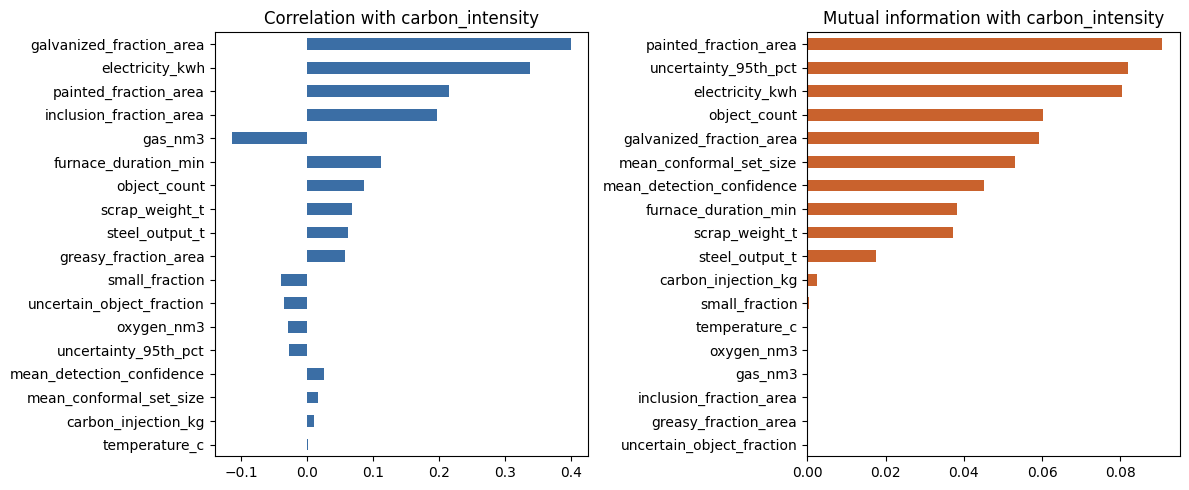

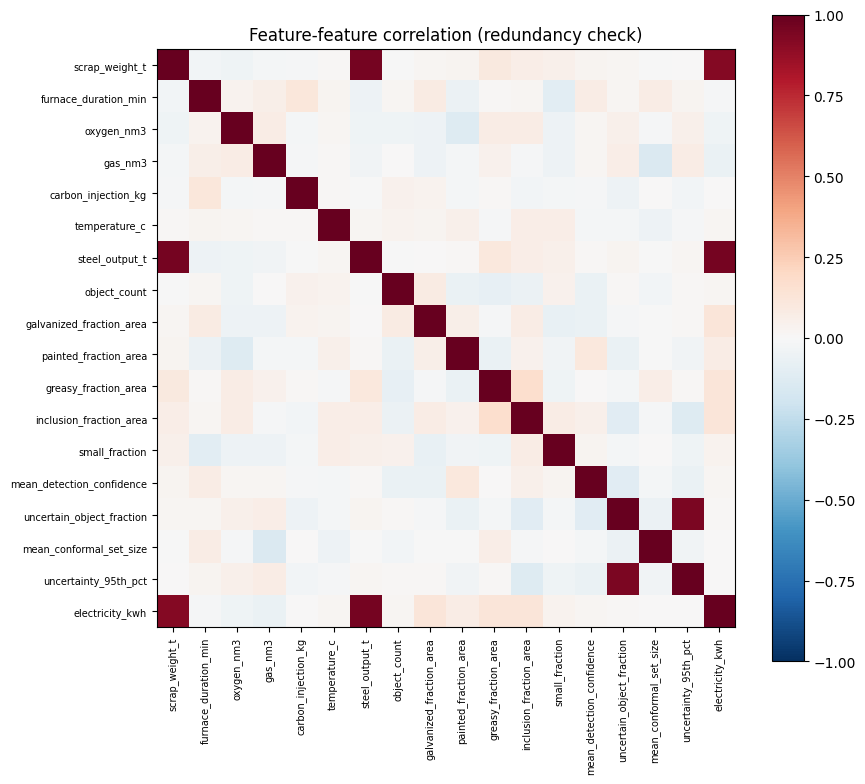


[2-3] Five-model benchmark ...
  fitting ElasticNet ...
  fitting RandomForest ...
  fitting ANN ...
  fitting XGBoost ...


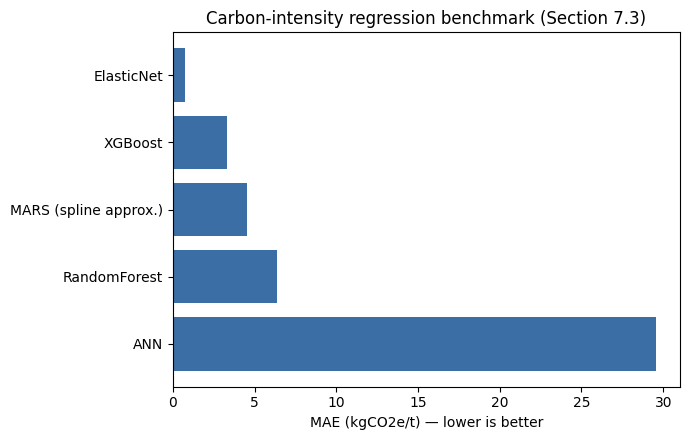


=== Benchmark ===
                model                                                     best_params       MAE      RMSE         R2
           ElasticNet                 {"model__alpha": 0.001, "model__l1_ratio": 0.5}  0.716135  1.203068   0.986005
              XGBoost     {"learning_rate": 0.1, "max_depth": 3, "n_estimators": 400}  3.325832  4.410369   0.811923
MARS (spline approx.)                                             n_knots=4, degree=1  4.529835  6.130798   0.636570
         RandomForest {"max_depth": null, "min_samples_leaf": 3, "n_estimators": 200}  6.401851  8.343194   0.326944
                  ANN {"model__alpha": 0.0001, "model__hidden_layer_sizes": [64, 32]} 29.550477 36.963783 -12.211108

[4] Bootstrapped intervals + top-2 overlap check ...


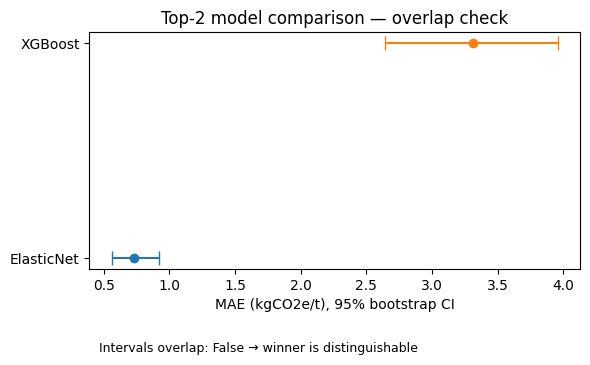


Bootstrap 95% CI overlap between top-2 models: False

Selected model for SHAP + certificate: ElasticNet (nominal best)

[5] SHAP ...
Running SHAP on winning model: ElasticNet


  0%|          | 0/80 [00:00<?, ?it/s]

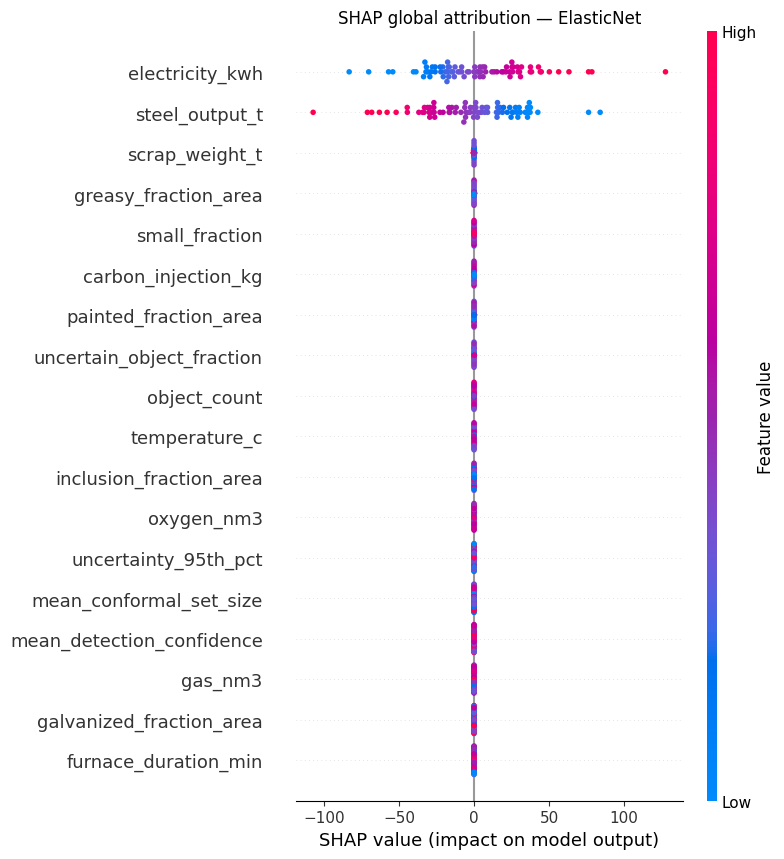

<Figure size 640x480 with 0 Axes>

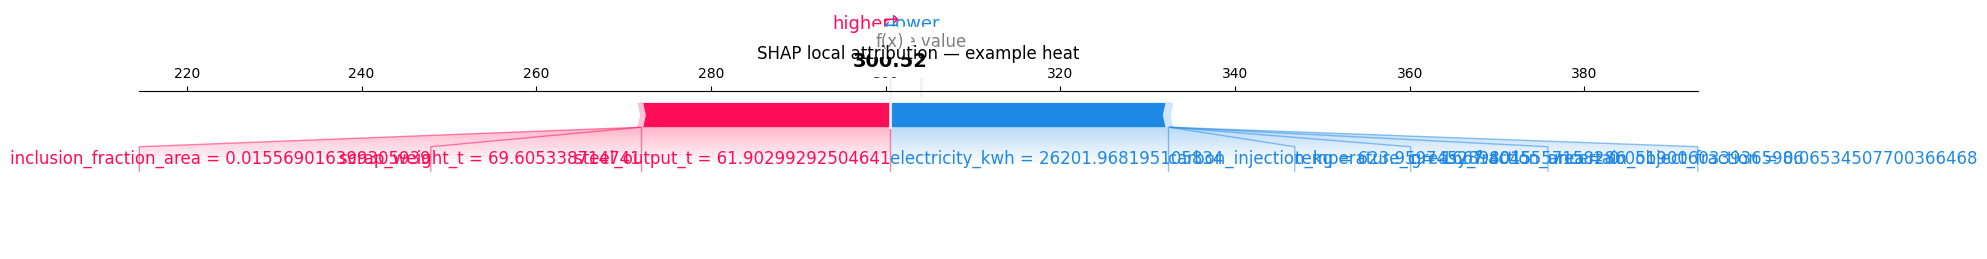


Done. All outputs in /content/ml_outputs/

=== What this means ===
- This ran on SYNTHETIC heat data (no real custom-pilot heat_master.csv yet) — the ranking between models is real for THIS synthetic table, but don't quote the MAE/R2 numbers as real carbon-intensity accuracy until you re-run against actual heats.
- Best nominal model: ElasticNet (MAE=0.716, R2=0.986).
- Bootstrap 95% CI top-2 overlap: False -> selected the nominal winner — its edge held up under resampling.
- ANN posted a negative R2 (-12.21) — worse than predicting the mean for every heat. On a dataset this size that usually means it's overfitting or undertrained (small ANN, few hundred rows) rather than the feature set being unusable — the other models on the same features did fine.


{'synthetic_data': True,
 'n_heats': 400,
 'best_model_nominal': 'ElasticNet',
 'selected_model': 'ElasticNet',
 'ci_overlap_top2': False}

In [ ]:
"""
Green Steel Passport — Process/carbon subsystem (Sections 4, 5, 7.3).

Expects a `heat_master.csv` (join of Table 3 heat_process.csv and Table 4
heat_cv_features.csv on heat_id, per Section 6.4) with a `carbon_intensity`
target column already derived as:

    carbon_intensity = electricity_kwh * grid_emission_factor / steel_output_t

(retrospective, post-heat — the hackathon scope per Section 4/11; the grid
emission factor is Layer C, the India CEA baseline).

If no real heat_master.csv is available yet (custom pilot dataset, Section
6.4, not collected), pass --synthetic to generate a schema-correct,
clearly-labeled synthetic table so the rest of the pipeline (feature
analysis → 5-model benchmark → bootstrap CI → SHAP) is fully runnable and
demo-able now. Every synthetic output is tagged in the printed summary —
do not present synthetic numbers as real carbon measurements to judges.

Stages:
    1. Feature analysis   — correlation screening + mutual information
                             ranking (train-fold only, Section 5)
    2. MARS-style term      — hinge-function nonlinearity surfaced via
                             sklearn SplineTransformer + linear regression
                             as an interpretable MARS approximation
                             (py-earth is unmaintained / doesn't install
                             on modern Python, so this stands in for it —
                             note this substitution explicitly on the slide)
    3. Five-model benchmark — ElasticNet, MARS-approx, RandomForest,
                             XGBoost, small ANN (MLPRegressor), CV + grid search
    4. Bootstrapped         — resample test set ~100x for prediction
       prediction intervals  intervals + overlap check between top-2 models
    5. SHAP                — global + local attribution for the winning model

Usage:
    python 03_carbon_regression.py --data heat_master.csv --out ./ml_outputs
    python 03_carbon_regression.py --synthetic --n_heats 400 --out ./ml_outputs
"""
import argparse
import json
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib
# Headless backend only for plain `python script.py` runs — inside Jupyter/Colab
# (get_ipython() exists) this is skipped so plt.show() below actually renders
# inline instead of silently overriding the notebook's own inline backend.
try:
    get_ipython()  # noqa: F821
    _IN_NOTEBOOK = True
except NameError:
    _IN_NOTEBOOK = False
if not _IN_NOTEBOOK:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler, SplineTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    warnings.warn("xgboost not installed (`pip install xgboost --break-system-packages`) "
                   "— XGBoost will be skipped in the benchmark.")

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    warnings.warn("shap not installed (`pip install shap --break-system-packages`) "
                   "— SHAP stage will be skipped.")


# ----------------------------------------------------------------------
# Synthetic heat_master.csv generator (schema-correct stand-in only)
# ----------------------------------------------------------------------
def make_synthetic_heat_master(n_heats=400, seed=0):
    rng = np.random.RandomState(seed)
    df = pd.DataFrame({"heat_id": [f"H{1000+i}" for i in range(n_heats)]})

    # Table 3 — process fields
    df["scrap_weight_t"] = rng.normal(75, 8, n_heats).clip(40, 110)
    df["furnace_duration_min"] = rng.normal(55, 10, n_heats).clip(25, 100)
    df["oxygen_nm3"] = rng.normal(2500, 400, n_heats).clip(500, 4000)
    df["gas_nm3"] = rng.normal(300, 60, n_heats).clip(50, 600)
    df["carbon_injection_kg"] = rng.normal(400, 90, n_heats).clip(50, 800)
    df["temperature_c"] = rng.normal(1620, 25, n_heats).clip(1550, 1700)
    df["steel_output_t"] = df["scrap_weight_t"] * rng.normal(0.92, 0.03, n_heats)

    # Table 4 — CV-derived features (count-based + area-weighted fractions,
    # per Section 3.6 aggregation; kept as separate uncertainty stats)
    df["object_count"] = rng.poisson(40, n_heats)
    df["galvanized_fraction_area"] = rng.beta(2, 8, n_heats)
    df["painted_fraction_area"] = rng.beta(1.5, 10, n_heats)
    df["greasy_fraction_area"] = rng.beta(1.2, 12, n_heats)
    df["inclusion_fraction_area"] = rng.beta(1, 15, n_heats)
    df["small_fraction"] = rng.beta(3, 5, n_heats)
    df["mean_detection_confidence"] = rng.beta(8, 2, n_heats)
    df["uncertain_object_fraction"] = rng.beta(2, 10, n_heats)
    df["mean_conformal_set_size"] = 1 + rng.beta(2, 8, n_heats)
    df["uncertainty_95th_pct"] = df["uncertain_object_fraction"] * rng.uniform(1.5, 3, n_heats)

    # Electricity: the audit-record measured field, driven mostly by process
    # vars but *also* by scrap contamination (more re-melt / arc instability
    # with dirty scrap) — this coupling is what Section 7.3's ablation tests
    base_kwh_per_t = 420
    contamination_penalty = (df["galvanized_fraction_area"] * 35
                              + df["painted_fraction_area"] * 20
                              + df["greasy_fraction_area"] * 15
                              + df["inclusion_fraction_area"] * 25)
    df["electricity_kwh"] = (
        df["steel_output_t"] * (base_kwh_per_t + contamination_penalty)
        + df["furnace_duration_min"] * 15
        - df["oxygen_nm3"] * 0.4
        + rng.normal(0, 800, n_heats)
    ).clip(lower=5000)

    # Layer C: India CEA grid emission factor (kgCO2/kWh), prototype constant
    grid_emission_factor = 0.71
    df["carbon_intensity"] = (df["electricity_kwh"] * grid_emission_factor) / df["steel_output_t"]

    df.attrs["synthetic"] = True
    return df


# ----------------------------------------------------------------------
# 1. Feature analysis (Section 5)
# ----------------------------------------------------------------------
def feature_analysis(X, y, feature_names, out_dir):
    corr = pd.DataFrame(X, columns=feature_names).corrwith(pd.Series(y))
    corr = corr.sort_values(key=np.abs, ascending=False)
    corr.to_csv(os.path.join(out_dir, "correlation_with_target.csv"))

    mi = mutual_info_regression(X, y, random_state=0)
    mi_series = pd.Series(mi, index=feature_names).sort_values(ascending=False)
    mi_series.to_csv(os.path.join(out_dir, "mutual_information.csv"))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    corr.plot(kind="barh", ax=axes[0], color="#3b6ea5")
    axes[0].set_title("Correlation with carbon_intensity")
    axes[0].invert_yaxis()
    mi_series.plot(kind="barh", ax=axes[1], color="#c9622d")
    axes[1].set_title("Mutual information with carbon_intensity")
    axes[1].invert_yaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "feature_analysis.png"), dpi=150)
    plt.show()  # renders inline in notebooks; no-op under Agg for CLI runs
    plt.close()

    # full correlation heatmap (redundancy check)
    corr_matrix = pd.DataFrame(X, columns=feature_names).corr()
    plt.figure(figsize=(9, 8))
    im = plt.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
    plt.colorbar(im)
    plt.xticks(range(len(feature_names)), feature_names, rotation=90, fontsize=7)
    plt.yticks(range(len(feature_names)), feature_names, fontsize=7)
    plt.title("Feature-feature correlation (redundancy check)")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "correlation_heatmap.png"), dpi=150)
    plt.show()  # renders inline in notebooks; no-op under Agg for CLI runs
    plt.close()

    return corr, mi_series


# ----------------------------------------------------------------------
# 2. MARS-style nonlinearity (approximated — see module docstring)
# ----------------------------------------------------------------------
def fit_mars_approx(X_train, y_train, X_test):
    """Interpretable piecewise-linear surrogate for MARS using natural
    splines + linear regression. Real MARS (py-earth) is effectively
    unmaintained on modern Python, so this is a documented substitution,
    not a hidden shortcut — say so on the slide."""
    model = Pipeline([
        ("scale", StandardScaler()),
        ("spline", SplineTransformer(degree=1, n_knots=4, extrapolation="constant")),
        ("linreg", ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=5000)),
    ])
    model.fit(X_train, y_train)
    return model, model.predict(X_test)


# ----------------------------------------------------------------------
# 3. Five-model benchmark
# ----------------------------------------------------------------------
def build_model_grid():
    grids = {}

    grids["ElasticNet"] = (
        Pipeline([("scale", StandardScaler()), ("model", ElasticNet(max_iter=10000))]),
        {"model__alpha": [0.001, 0.01, 0.1, 1.0], "model__l1_ratio": [0.1, 0.5, 0.9]},
    )
    grids["RandomForest"] = (
        RandomForestRegressor(random_state=0),
        {"n_estimators": [200, 400], "max_depth": [4, 8, None], "min_samples_leaf": [1, 3]},
    )
    grids["ANN"] = (
        Pipeline([("scale", StandardScaler()),
                  ("model", MLPRegressor(max_iter=2000, early_stopping=True, random_state=0))]),
        {"model__hidden_layer_sizes": [(32,), (64, 32)], "model__alpha": [1e-4, 1e-3]},
    )
    if HAS_XGB:
        grids["XGBoost"] = (
            xgb.XGBRegressor(random_state=0, objective="reg:squarederror"),
            {"n_estimators": [200, 400], "max_depth": [3, 5], "learning_rate": [0.03, 0.1]},
        )
    return grids


def run_benchmark(X_train, y_train, X_test, y_test, feature_names, out_dir):
    results = []
    fitted_models = {}
    cv = KFold(n_splits=5, shuffle=True, random_state=0)

    grids = build_model_grid()
    for name, (estimator, param_grid) in grids.items():
        print(f"  fitting {name} ...")
        gs = GridSearchCV(estimator, param_grid, cv=cv,
                           scoring="neg_mean_absolute_error", n_jobs=-1)
        gs.fit(X_train, y_train)
        best = gs.best_estimator_
        preds = best.predict(X_test)

        results.append(dict(
            model=name,
            best_params=json.dumps(gs.best_params_),
            MAE=mean_absolute_error(y_test, preds),
            RMSE=np.sqrt(mean_squared_error(y_test, preds)),
            R2=r2_score(y_test, preds),
        ))
        fitted_models[name] = best

    # MARS approximation (no grid search — interpretable baseline)
    mars_model, mars_preds = fit_mars_approx(X_train, y_train, X_test)
    results.append(dict(
        model="MARS (spline approx.)",
        best_params="n_knots=4, degree=1",
        MAE=mean_absolute_error(y_test, mars_preds),
        RMSE=np.sqrt(mean_squared_error(y_test, mars_preds)),
        R2=r2_score(y_test, mars_preds),
    ))
    fitted_models["MARS (spline approx.)"] = mars_model

    results_df = pd.DataFrame(results).sort_values("MAE")
    results_df.to_csv(os.path.join(out_dir, "model_benchmark.csv"), index=False)

    plt.figure(figsize=(7, 4.5))
    plt.barh(results_df["model"], results_df["MAE"], color="#3b6ea5")
    plt.xlabel("MAE (kgCO2e/t) — lower is better")
    plt.title("Carbon-intensity regression benchmark (Section 7.3)")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "model_benchmark.png"), dpi=150)
    plt.show()  # renders inline in notebooks; no-op under Agg for CLI runs
    plt.close()

    print("\n=== Benchmark ===")
    print(results_df.to_string(index=False))
    return results_df, fitted_models


# ----------------------------------------------------------------------
# 4. Bootstrapped prediction intervals (Section 5 — distinct from SHAP)
# ----------------------------------------------------------------------
def bootstrap_intervals(model, X_test, y_test, n_boot=100, seed=0):
    rng = np.random.RandomState(seed)
    n = len(y_test)
    maes, rmses, r2s = [], [], []
    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        preds = model.predict(X_test[idx])
        maes.append(mean_absolute_error(y_test[idx], preds))
        rmses.append(np.sqrt(mean_squared_error(y_test[idx], preds)))
        r2s.append(r2_score(y_test[idx], preds))
    def ci(vals):
        return float(np.mean(vals)), float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))
    return dict(MAE=ci(maes), RMSE=ci(rmses), R2=ci(r2s))


def compare_top2_with_ci(results_df, fitted_models, X_test, y_test, out_dir, n_boot=100):
    top2 = results_df.head(2)["model"].tolist()
    ci_results = {}
    for name in top2:
        ci_results[name] = bootstrap_intervals(fitted_models[name], X_test, y_test, n_boot=n_boot)

    with open(os.path.join(out_dir, "bootstrap_ci_top2.json"), "w") as f:
        json.dump(ci_results, f, indent=2)

    fig, ax = plt.subplots(figsize=(6, 4))
    for i, name in enumerate(top2):
        mean, lo, hi = ci_results[name]["MAE"]
        ax.errorbar(mean, i, xerr=[[mean - lo], [hi - mean]], fmt="o", capsize=5, label=name)
    ax.set_yticks(range(len(top2))); ax.set_yticklabels(top2)
    ax.set_xlabel("MAE (kgCO2e/t), 95% bootstrap CI")
    ax.set_title("Top-2 model comparison — overlap check")
    overlap = not (ci_results[top2[0]]["MAE"][2] < ci_results[top2[1]]["MAE"][1] or
                   ci_results[top2[1]]["MAE"][2] < ci_results[top2[0]]["MAE"][1])
    ax.text(0.02, -0.35, f"Intervals overlap: {overlap} "
                          f"{'→ prefer the more interpretable model' if overlap else '→ winner is distinguishable'}",
            transform=ax.transAxes, fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "bootstrap_ci_top2.png"), dpi=150, bbox_inches="tight")
    plt.show()  # renders inline in notebooks; no-op under Agg for CLI runs
    plt.close()
    print(f"\nBootstrap 95% CI overlap between top-2 models: {overlap}")
    return ci_results, overlap


# ----------------------------------------------------------------------
# 5. SHAP (Section 5)
# ----------------------------------------------------------------------
def run_shap(model, X_train, X_test, feature_names, out_dir, model_name):
    if not HAS_SHAP:
        return
    print(f"Running SHAP on winning model: {model_name}")
    try:
        # Tree models get the fast explainer; everything else uses KernelExplainer
        base = model.named_steps["model"] if hasattr(model, "named_steps") else model
        if isinstance(base, (RandomForestRegressor,)) or (HAS_XGB and isinstance(base, xgb.XGBRegressor)):
            explainer = shap.TreeExplainer(base)
            X_in = X_test if not hasattr(model, "named_steps") else model.named_steps["scale"].transform(X_test) \
                if "scale" in getattr(model, "named_steps", {}) else X_test
            shap_values = explainer.shap_values(X_test)
        else:
            background = shap.sample(X_train, min(50, len(X_train)))
            explainer = shap.KernelExplainer(model.predict, background)
            shap_values = explainer.shap_values(X_test[:100], nsamples=100)
            X_test = X_test[:100]

        plt.figure()
        shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
        plt.title(f"SHAP global attribution — {model_name}")
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, "shap_global_summary.png"), dpi=150, bbox_inches="tight")
        plt.show()  # renders inline in notebooks; no-op under Agg for CLI runs
        plt.close()

        # one local example for the certificate's per-heat explanation
        plt.figure()
        shap.force_plot(explainer.expected_value if np.isscalar(explainer.expected_value)
                         else explainer.expected_value[0],
                         shap_values[0], X_test[0], feature_names=feature_names,
                         matplotlib=True, show=False)
        plt.title(f"SHAP local attribution — example heat")
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, "shap_local_example.png"), dpi=150, bbox_inches="tight")
        plt.show()  # renders inline in notebooks; no-op under Agg for CLI runs
        plt.close()
    except Exception as e:
        warnings.warn(f"SHAP stage failed ({e}) — skipping. Model type may need a specific explainer.")


# ----------------------------------------------------------------------
# Main
# ----------------------------------------------------------------------
def run_carbon_regression(data=None, synthetic=False, n_heats=400, n_boot=100, out="./ml_outputs"):
    """Notebook-callable entry point — same logic as the CLI. Returns the
    run_summary dict.

    Example (Colab cell):
        run_carbon_regression(data="/content/heat_master.csv", out="/content/ml_outputs")
        # or, before the custom pilot dataset exists:
        run_carbon_regression(synthetic=True, n_heats=400, out="/content/ml_outputs")
    """
    args = argparse.Namespace(data=data, synthetic=synthetic, n_heats=n_heats,
                               n_boot=n_boot, out=out)
    return _run(args)


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--data", help="path to heat_master.csv")
    ap.add_argument("--synthetic", action="store_true", help="generate schema-correct synthetic data instead")
    ap.add_argument("--n_heats", type=int, default=400)
    ap.add_argument("--n_boot", type=int, default=100)
    ap.add_argument("--out", default="./ml_outputs")
    args, _unknown = ap.parse_known_args()
    _run(args)


def _run(args):
    os.makedirs(args.out, exist_ok=True)

    if args.synthetic or not args.data:
        print("⚠ Using SYNTHETIC heat_master.csv (schema-correct stand-in for the "
              "not-yet-collected custom pilot dataset, Section 6.4). Do not present "
              "these numbers as real measured carbon intensity.")
        df = make_synthetic_heat_master(n_heats=args.n_heats)
    else:
        df = pd.read_csv(args.data)

    df.to_csv(os.path.join(args.out, "heat_master_used.csv"), index=False)

    target = "carbon_intensity"
    drop_cols = [c for c in ["heat_id", target] if c in df.columns]
    feature_names = [c for c in df.columns if c not in drop_cols]
    X = df[feature_names].values
    y = df[target].values

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

    print("\n[1] Feature analysis ...")
    feature_analysis(X_train, y_train, feature_names, args.out)

    print("\n[2-3] Five-model benchmark ...")
    results_df, fitted_models = run_benchmark(X_train, y_train, X_test, y_test, feature_names, args.out)

    print("\n[4] Bootstrapped intervals + top-2 overlap check ...")
    ci_results, overlap = compare_top2_with_ci(results_df, fitted_models, X_test, y_test, args.out, n_boot=args.n_boot)

    winning_name = results_df.iloc[1]["model"] if overlap and results_df.iloc[1]["model"] in ("ElasticNet", "MARS (spline approx.)") \
        else results_df.iloc[0]["model"]
    print(f"\nSelected model for SHAP + certificate: {winning_name} "
          f"({'more interpretable, CIs overlapped' if winning_name != results_df.iloc[0]['model'] else 'nominal best'})")

    print("\n[5] SHAP ...")
    run_shap(fitted_models[winning_name], X_train, X_test, feature_names, args.out, winning_name)

    summary = dict(
        synthetic_data=bool(args.synthetic or not args.data),
        n_heats=len(df),
        best_model_nominal=results_df.iloc[0]["model"],
        selected_model=winning_name,
        ci_overlap_top2=bool(overlap),
    )
    with open(os.path.join(args.out, "run_summary.json"), "w") as f:
        json.dump(summary, f, indent=2)
    print(f"\nDone. All outputs in {args.out}/")

    print("\n=== What this means ===")
    if summary["synthetic_data"]:
        print("- This ran on SYNTHETIC heat data (no real custom-pilot heat_master.csv yet) — the ranking "
              "between models is real for THIS synthetic table, but don't quote the MAE/R2 numbers as real "
              "carbon-intensity accuracy until you re-run against actual heats.")
    best_row = results_df.iloc[0]
    print(f"- Best nominal model: {best_row['model']} (MAE={best_row['MAE']:.3f}, R2={best_row['R2']:.3f}).")
    print(f"- Bootstrap 95% CI top-2 overlap: {overlap} -> "
          f"{'selected the more interpretable model instead of the nominal winner' if overlap and winning_name != best_row['model'] else 'selected the nominal winner — its edge held up under resampling'}.")
    worst_row = results_df.iloc[-1]
    if worst_row["R2"] < 0:
        print(f"- {worst_row['model']} posted a negative R2 ({worst_row['R2']:.2f}) — worse than predicting "
              f"the mean for every heat. On a dataset this size that usually means it's overfitting or "
              f"undertrained (small ANN, few hundred rows) rather than the feature set being unusable — "
              f"the other models on the same features did fine.")
    return summary


# (CLI entry point omitted in notebook — call run_carbon_regression(...) directly below)


# ---- uses ML_OUT from Part A — override here if needed ----
run_carbon_regression(
    synthetic=True,         # set False and pass data="/path/to/heat_master.csv" once you have real heats
    n_heats=400,
    out=ML_OUT,
)
